# Проект SocialSearch

## Тематические статьи
Про графы:
- [Хорошая статья на хабре про кластеризацию графив](https://habr.com/ru/company/dca/blog/265077/)
- [алгоритм louvain](https://louvain-igraph.readthedocs.io/en/latest/index.html)
- [Awesome Community Detection Research Papers](https://github.com/benedekrozemberczki/awesome-community-detection)


Про нахождение информации о человеке:
- https://bsfo.ru/threads/probiv-cheloveka-v-vk.4110/
- https://www.iphones.ru/iNotes/705983
- https://cryptoworld.su/5-sposobov-probit-informaciyu-o-cheloveke-v-seti/
- https://habr.com/en/company/echelon/blog/321754/ Отличная статья на хабре
    
    
Лайфкаки по поиску информации:
- https://vk.com/feed?obj=1&q=&section=mentions
- [Каталог пользователей вк](https://vk.com/catalog.php)
- https://vk.com/foaf.php?id=245089915 Посмотреть код страницы
- http://сервисы.гувм.мвд.рф/info-service.htm?sid=2000 Провека действительности паспорта

Конкуренты (похожие проекты):
- https://bazaman.ru/ Нахождение человека по данным. Работает хреново
- https://poiski-people.ru/instrukziya.html Плохо работает [То, что нашли обо мне](https://poiski-people.ru/rossiya/moskva/boris-novichkov-moskva-90185.html) 
- https://people.yandex.ru (Поиск людей по различной информации)
- https://poisk-help.ru/ Работает плохо [Обо мне](https://poisk-help.ru/rossiya/moskva/boris-novichkov-moskva-2959.html)
- http://spys.one/vk/ Банальное копирование вк. Только информация со страницы пользователя
- https://vk.barkov.net/userinfo.aspx Требует доступ к странице. Базовая информация

Получение ключа доступа пользователя для vk api
https://oauth.vk.com/authorize?client_id=7091370&scope=photos,audio,video,docs,notes,pages,status,offers,questions,wall,groups,notifications,stats,ads,offline,docs,pages,stats,notifications,wall,friends&response_type=token

# Задачи проекта: 
1. Найти человека по минимальномо количеству известных о нем данных
2. Получить всю возможную инфомацию о человеке из открытых источников (социальные сети, гос. порталы, гугл, некоторые сайты)
3. Проанализировать (аналитичестки, с помощью ML) 
4. Предоставить все в красивом человеко-читаемом виде конечному потребителю (пользователю данного ресурса)

## Информация о человеке
### Базовые аспекты
*Поля страницы вк: first_name, last_name, photo_200, sex, bdate, city, country, relatives, home_town, maiden_name, relation*
- Имя
- Вевичья фамилия
- Фото
- Пол
- Возраст
- Страна
- Родной город
- Родственники


### Основная деятельность (в настоящем / прошлом)
*Поля страницы вк: career, education, occupation, schools, universities, military*
- Школа (класс, год)
- Вуз (факультет, курс, год)
- Работа (направленность, год)
- Бизнес (направления, сайт и пр)

### Сетевая жизнь / Контакты
*Поля страницы вк: nickname, online, site, exports, contacts, verified, last_seen, connections, followers_count*
- Сайт
- Все социальные сети
- Подписчики
- Verify
- Приватный аккаунт

### Интересы / Занятия
*Поля страницы вк: books, activities, movies, music, tv, trending, games, interests, quotes*
- Увлечения
- Хобби
- Музыка Фильмы Игры Книги

### Характеристика / Анализ
*Поля страницы вк: status, counters, personal, about*

*Информация на основе всех имеющихся данных*
- Экстраверт / Интроверт (в процентах)
- Популярность в сети (Подписчики, друзья и тд)
- Сетевая доступность (в процентах). Количество личной информации в сети
- Общественный статус (один из нескольких вариантов)
- Процент одиночных друзей (не состоящих в сообществах испытуемого)
- Придумать еще что-нибудь!

## Социальные сообщества человека
**Любые группы людей, к которым относится испытуемый:**
- Социальные объединения среди друзей
- Сообщества на основе общих групп
- Виртуальное объединение на основе общего интереса (несвязные друзья программисты)

### Операции над сообществами
- Поиск полного коллектива из небольшой его части

### Параметры каждого объединения
- Список всех объединяющих коллектив факторы (место учебы, интересы, возраст, пол и пр)
- Связность сообщества (исходя из графа)
- Размер сообщества (количество участников)
- Тут можно много чего еще придумать!


### Идеи
- брать людей связанных отношениями (поле на странице пользователя). Таким образом находить семьи и прочее


In [2]:
import numpy as np
import pandas as pd
from skimage import io
import networkx as nx
import random
import matplotlib.pyplot as plt
import vk
from vkcommunity import VKCommunity
import warnings
warnings.filterwarnings("ignore")
import collections
from collections import Counter
import datetime
from time import time, sleep
import json
import functools
from vkuser import VKUser
import networkx as nx
import math
import pickle
from queue import Queue
from main import *
from instapi import *
from tools import *
# %matplotlib qt
%matplotlib inline
# MemoryCache.clear_memory()
InstRequest.start_agents(5)
# InstRequest.print_stat()

DEBUG    Add inst agent: agniiazhdanova541
DEBUG    Add inst agent: kiraovchinnikova680
DEBUG    Add inst agent: varvarakniazeva9295
DEBUG    Add inst agent: agniiakolesnikova5157
DEBUG    Add inst agent: aleksandrakniazeva7955


DEBUG    * Inst api call: get_follows, agent: iaroslavamoiseeva5070
DEBUG    * Inst api call: get_followers, agent: iaroslavamoiseeva5070
DEBUG    * Inst api call: get_followers, agent: iaroslavamoiseeva5070
DEBUG    * Inst api call: get_followers, agent: iaroslavamoiseeva5070
DEBUG    * Inst api call: get_followers, agent: sabinaermakova235
DEBUG    * Inst api call: get_followers, agent: shirleycarrington473
DEBUG    * Inst api call: get_followers, agent: reginablinova191
DEBUG    * Inst api call: get_followers, agent: ameliiasharapova9216
DEBUG    * Inst api call: get_followers, agent: varvaramikheeva3584
DEBUG    * Inst api call: get_followers, agent: aleksandrakniazeva7955
DEBUG    * Inst api call: get_followers, agent: shirleydonovan84
DEBUG    * Inst api call: get_followers, agent: darinasokolova4970
DEBUG    * Inst api call: get_followers, agent: leilagordeeva2201
DEBUG    * Inst api call: get_followers, agent: reginalikhachiova8613
DEBUG    * Inst api call: get_followers, agent

DEBUG    * Inst api call: get_followers, agent: ameliiafedoseeva674
DEBUG    * Inst api call: get_followers, agent: agniiazhdanova541
DEBUG    * Inst api call: get_followers, agent: agniiakolesnikova5157
DEBUG    * Inst api call: get_followers, agent: aleksandraartemeva3635
DEBUG    * Inst api call: get_followers, agent: leilagordeeva2201
DEBUG    * Inst api call: get_followers, agent: iaroslavaalekseeva5882
DEBUG    * Inst api call: get_followers, agent: lidiiasokolova4179
DEBUG    * Inst api call: get_followers, agent: dinaalekseeva4958
DEBUG    * Inst api call: get_followers, agent: reginakarpova5261
DEBUG    * Inst api call: get_followers, agent: kiralobanova1045
DEBUG    * Inst api call: get_followers, agent: aksinianazarova8923
DEBUG    * Inst api call: get_followers, agent: kamillamorozova3484
DEBUG    * Inst api call: get_followers, agent: ameliiasharapova9216
DEBUG    * Inst api call: get_followers, agent: elizavetabeliaeva8516
DEBUG    * Inst api call: get_followers, agent: k

DEBUG    * Inst api call: get_followers, agent: varvarabolshakova8794
DEBUG    * Inst api call: get_followers, agent: lidiiasokolova4179
DEBUG    * Inst api call: get_followers, agent: aksinianazarova8923
DEBUG    * Inst api call: get_followers, agent: sabinaovchinnikova9754
DEBUG    * Inst api call: get_followers, agent: kamillabelousova5951
DEBUG    * Inst api call: get_followers, agent: tamarakulakova2946
DEBUG    * Inst api call: get_followers, agent: sabinaalekseeva1275
DEBUG    * Inst api call: get_followers, agent: elizavetabobyliova5180
DEBUG    * Inst api call: get_followers, agent: dianecoleman918
DEBUG    * Inst api call: get_followers, agent: reginalikhachiova8613
DEBUG    * Inst api call: get_followers, agent: lidiiavinogradova123
DEBUG    * Inst api call: get_followers, agent: shirleycarrington473
DEBUG    * Inst api call: get_followers, agent: iaroslavamoiseeva5070
DEBUG    * Inst api call: get_followers, agent: reginablinova191
DEBUG    * Inst api call: get_followers, a

DEBUG    * Inst api call: get_follows, agent: elviramoiseeva1076
DEBUG    * Inst api call: get_follows, agent: varvarakniazeva9295
DEBUG    * Inst api call: get_follows, agent: sabinaovchinnikova9754
DEBUG    * Inst api call: get_follows, agent: varvaratitova9574
DEBUG    * Inst api call: get_follows, agent: varvaraaksionova5004
DEBUG    * Inst api call: get_follows, agent: dinaalekseeva4958
DEBUG    * Inst api call: get_follows, agent: dinafomichiova4713
DEBUG    * Inst api call: get_follows, agent: elizavetaefremova4173
DEBUG    * Inst api call: get_follows, agent: lidiiarogova4743
DEBUG    * Inst api call: get_follows, agent: tamarakulakova2946
DEBUG    * Inst api call: get_follows, agent: sabinaalekseeva1275
DEBUG    * Inst api call: get_follows, agent: varvarabolshakova8794
DEBUG    * Inst api call: get_follows, agent: dianecoleman918
DEBUG    * Inst api call: get_follows, agent: reginapanfilova1678
DEBUG    * Inst api call: get_follows, agent: shirleycarrington473
DEBUG    * Inst

DEBUG    * Inst api call: get_follows, agent: ameliiapakhomova8339
DEBUG    * Inst api call: get_follows, agent: agatakrasilnikova5391
DEBUG    * Inst api call: get_follows, agent: dianecoleman918
DEBUG    * Inst api call: get_follows, agent: leilakhokhlova1638
DEBUG    * Inst api call: get_follows, agent: kamillamorozova3484
DEBUG    * Inst api call: get_follows, agent: dinapetukhova3310
DEBUG    * Inst api call: get_follows, agent: tamarazueva1062
DEBUG    * Inst api call: get_follows, agent: christinapearcy30
DEBUG    * Inst api call: get_follows, agent: varvaratitova9574
DEBUG    * Inst api call: get_follows, agent: kiraovchinnikova680
DEBUG    * Inst api call: get_follows, agent: iaroslavamoiseeva5070
DEBUG    * Inst api call: get_follows, agent: shirleydonovan84
DEBUG    * Inst api call: get_follows, agent: varvarasafonova5641
DEBUG    * Inst api call: get_follows, agent: elizavetabobyliova5180
DEBUG    * Inst api call: get_follows, agent: iaroslavaignatova8267
DEBUG    * Inst ap

# timeit communities_from_graph eps:0.07975 time:151.0838647
# timeit pools eps:0.07985 time:151.0839608


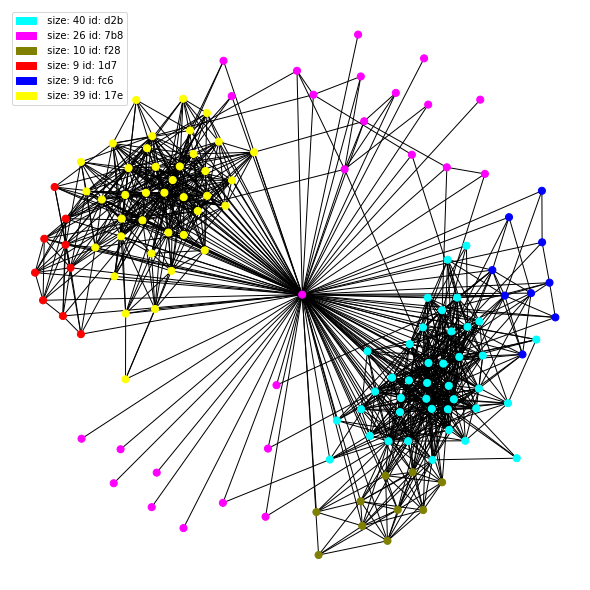

# timeit show_graph eps:0.51056 time:151.730499
# timeit color_graph eps:3.55247 time:151.730673


In [12]:
InstUser('sin_and_misery848').friends().color_graph()

In [11]:
url = 'https://vk.com/lehahel'
user = VKUser(url)
user_key_words = user.get_key_words()
print('Keywords:')
print(user_key_words)
print()
inst_usernames = user.friends().shorten_data()['username_instagram']
print('Instagram friends usernames list length:')
print(len(inst_usernames))
print()
community = InstCommunity(inst_usernames).valid_users
community = community.select(1000, rand=False).friends(include_self=True)
InstCommunity(Tools.best_names_matches(community.select().get_key_words(), user_key_words)).select(10).print()
# community.print()

Keywords:
['Леша Попов', 'Леша', 'Попов', 'lehahel', 'lehahel2013', 'yan_gleen']

Instagram friends usernames list length:
68

al.wx Lesha Novitsky             https://instagram.com/al.wx/
yan_gleen Леша                   https://instagram.com/yan_gleen/
sin_and_misery848 Даниил Попов   https://instagram.com/sin_and_misery848/
_beautiful_chance_ Анастасия Попова 0.9090909090909091  https://instagram.com/_beautiful_chance_/
danilpopkov_ Данил Попков 0.9090909090909091  https://instagram.com/danilpopkov_/
goryanova Лероша 0.8333333333333334  https://instagram.com/goryanova/
lozkinkot Леся Никитина 0.8      https://instagram.com/lozkinkot/
kostovarova Lesya Kostovarova 0.8  https://instagram.com/kostovarova/
infi_grom_nity Леша Громов 0.782608695652174  https://instagram.com/infi_grom_nity/
leshabud alexey budnikov 0.7692307692307693  https://instagram.com/leshabud/


In [5]:
MemoryCache.save_memory()

In [28]:
from instagram import WebAgent, WebAgentAccount
from instagram import Account, Media
from glbal import logger
accounts_data = [('agniiamuraviova212', '58nwNOT6iA'), 
                 ('dinafomichiova4713', 'hjSOZ5Sx3g'), 
                 ('lidiiadrozdova5662', 'hOQXuhdJxX'), 
                 ('darinabobrova8107', 'AnNInVZcgP'), 
                 ('varvarabolshakova8794', 'PyvFqtfh1g'), 
                 ('agniiazhdanova541', 'S4ApKhUBKh'), 
                 ('kiraovchinnikova680', '414LKKrHPa'), 
                 ('varvarakniazeva9295', 'sWXduOEjWz')]
accounts = []
# for username, password in accounts_data:
#     agent = WebAgentAccount(username)
#     agent.auth(password)
#     accounts.append(agent)
agent = WebAgentAccount('agniiamuraviova212')
agent.auth('58nwNOT6iA')
agent.get_media(Account('0sweetblood'))
Account('0sweetblood').__dict__

{'id': '8431569371',
 'username': '0sweetblood',
 'full_name': 'my God is Mirai 🖤',
 'profile_pic_url': 'https://instagram.fhel3-1.fna.fbcdn.net/vp/a792b441e9fa9b5dc3d60ba474662e01/5E27A425/t51.2885-19/s150x150/69265980_474571963272732_3993667708028715008_n.jpg?_nc_ht=instagram.fhel3-1.fna.fbcdn.net',
 'profile_pic_url_hd': 'https://instagram.fhel3-1.fna.fbcdn.net/vp/5979f30aff79806aab9fc12b2090dfd2/5E37CDD5/t51.2885-19/s320x320/69265980_474571963272732_3993667708028715008_n.jpg?_nc_ht=instagram.fhel3-1.fna.fbcdn.net',
 'fb_page': None,
 'biography': '',
 'follows_count': 235,
 'followers_count': 25,
 'media_count': 9,
 'is_private': True,
 'is_verified': False,
 'country_block': False,
 'media': set(),
 'follows': set(),
 'followers': set()}

In [164]:
количество элементов в запросе, время между запросами,сколько продержалось до 429 ошибки
50 0.5 150 agniiamuraviova212
50 0.5 68  dinafomichiova4713
50 0.5 100 lidiiadrozdova5662
50 0.5 100 agniiamuraviova212 опять (1) через примерно 5 минут
50 0.5 18  dinafomichiova4713 опять через 4 минуты
50 0.5 66  darinabobrova8107
50 0.5 100 varvarabolshakova8794
50 2   100 agniiazhdanova541
50 2  102  kiraovchinnikova680
50 0  100  lidiiadrozdova5662 спустя 10 минут (очнулся через 9 минут)
50 0  100  lidiiadrozdova5662 он же
Последовательно запускаю 2 клиента
2x 50 0(не делаю sleep так и так запросы выполняются последовательно) 66 agniiamuraviova212 dinafomichiova4713 
Повторяю тоже самое. Через 9 минут проснулся от 429
2x 50 0 200
3x 50 0 100
3x 50 0 109 (каждый запрос в тройке выполняется одновременно, каждая тройка последовательно)
1x 20 6 376
1x 20 2 159
получить информацию о профиле безлимитное количество раз. пробовал паралельно запустить 1000 запросов. 
Работает без проблем
1x 100 0 64
1x 100 0 69
1x 100 0 67
1x 100 0 61
1x 100 0 66
200 0 47
200 0 48
200 0 47
50 0 107
50 0 108
100 0 74
100 0 72
100 0 30 (другой query_hash)
100 0 32 подождал 3 минуты

SyntaxError: invalid syntax (<ipython-input-164-c1e288536baa>, line 1)

In [2]:
l = ['trendcdmx', 'lemonland3', 'eldarik_sharafiev', 'vikulia_voinu', 'vasea3261']

In [123]:
def f(agent, count=50):
    try:
        res = agent.get_followers(Account(random.choice(l)), limit=count, count=count)
    except:
        return False
    return True

In [202]:
%%time
k = 0
while True:
    res = [
        ThreadResult(target=f, args=(accounts[i],))
        for i in range(1)
    ]
    res = [
        item.execute()
        for item in res
    ]
    if not all(res):
        break
    k += 1
    print(k)
    time.sleep(0.5)

CPU times: user 119 ms, sys: 1.85 ms, total: 120 ms
Wall time: 680 ms


In [13]:
# agent = WebAgentAccount('agniiamuraviova212')
# agent.auth('58nwNOT6iA')
# agent.get_media(Account('putin_leader'))
# Account('putin_leader').full_name
qs = ['c76146de99bb02f6415203be841dd25a']

In [31]:
import random
import time
k = 0
while True:
    count=100
    k += 1
    res = accounts[1].get_followers(Account(random.choice(l)), limit=count, count=count, query_hash='f2405b236d85e8296cf30347c9f08c2a')
    print(len(res[0]), k)
#     break
#     time.sleep(2)
    

UnexpectedResponse: Get unexpected response from 'https://www.instagram.com/graphql/query/?query_hash=f2405b236d85e8296cf30347c9f08c2a&variables=%7B%22id%22%3A%2212742941164%22%2C%22first%22%3A100%7D'
Error: 'edge_followed_by'

In [24]:
from instagram import WebAgent, Account, WebAgentAccount

with open('instagram_accounts_data.txt', 'r') as f:
    inst_accounts_raw_data = f.read()
    
good_agents = []
inst_accounts_data = []
for line in inst_accounts_raw_data.split('\n'):
    line = line.strip()
    elements = line.split(':')
    if len(elements) == 4:
        inst_accounts_data.append((elements[0], elements[1]))
    
for username, password in inst_accounts_data:
    try:
        ac = WebAgentAccount(username)
        ac.auth(password)
        good_agents.append((username, password))
        print('GOOD', username)
    except:
        print('BAD', username)
        
print('All accounts count:', len(inst_accounts_data))
print('Good accounts count:', len(good_agents))
print('Bad accounts count:', len(inst_accounts_data) - len(good_agents))
print(repr(good_agents))

GOOD agniiamuraviova212
GOOD dinafomichiova4713
GOOD lidiiadrozdova5662
GOOD darinabobrova8107
BAD karolinafiodorova7156
GOOD varvarabolshakova8794
GOOD agniiazhdanova541
GOOD kiraovchinnikova680
GOOD varvarakniazeva9295
BAD agniiafedoseeva9784
GOOD agniiakolesnikova5157
BAD karolinaignatova5231
BAD dinarogova4678
BAD darinasidorova5511
BAD darinasazonova2973
GOOD aleksandrakniazeva7955
GOOD tamarazueva1062
BAD elvirazhukova7840
BAD dinafedoseeva5862
GOOD iaroslavaignatova8267
BAD leilakovaliova6560
GOOD lidiiarogova4743
GOOD ameliiafedoseeva674
BAD ameliiasergeeva946
BAD darinabogdanova403
BAD iaroslavabespalova1694
GOOD reginapanfilova1678
BAD sabinastepanova1794
GOOD varvarakhokhlova3462
GOOD agatasuvorova6583
GOOD lidiiaershova6477
GOOD varvaraaksionova5004
GOOD kamillabelousova5951
GOOD elizavetakudriavtseva6928
GOOD tamarakulakova2946
GOOD elizavetabobyliova5180
GOOD reginalikhachiova8613
BAD leilaodintsova291
BAD leilakalinina4900
BAD iaroslavabelousova121
BAD agniiabeloziorova5

In [13]:
good = [('agniiamuraviova212', '58nwNOT6iA'), ('dinafomichiova4713', 'hjSOZ5Sx3g'), ('lidiiadrozdova5662', 'hOQXuhdJxX'), ('darinabobrova8107', 'AnNInVZcgP'), ('varvarabolshakova8794', 'PyvFqtfh1g'), ('agniiazhdanova541', 'S4ApKhUBKh'), ('kiraovchinnikova680', '414LKKrHPa'), ('varvarakniazeva9295', 'sWXduOEjWz'), ('agniiafedoseeva9784', 'yhNb3U7fYd'), ('agniiakolesnikova5157', 'rDfIoQSOIf'), ('aleksandrakniazeva7955', 'V3WYCG1fQ4'), ('tamarazueva1062', 'vZ5r7U8pBe'), ('iaroslavaignatova8267', 'KuxLCuSD0V'), ('leilakovaliova6560', 'zEhAFUjFGU'), ('lidiiarogova4743', 'L9RtTctnuG'), ('ameliiafedoseeva674', 'v7iCXPTxGp'), ('ameliiasergeeva946', 'z5XYZp9iSM'), ('reginapanfilova1678', 'xFzyYhKITD'), ('sabinastepanova1794', '1nlR5Tecpl'), ('varvarakhokhlova3462', 'Y01DVVGrJp'), ('agatasuvorova6583', '8DelwWXf5x'), ('lidiiaershova6477', '40FkUNxdVm'), ('varvaraaksionova5004', 'S6KLputgGG'), ('kamillabelousova5951', 'b0Giqt1aWI'), ('elizavetakudriavtseva6928', 'lg0GbPUxJv'), ('tamarakulakova2946', 'Wf8wjgwL3B'), ('elizavetabobyliova5180', 'JsbhlnEr4B'), ('reginalikhachiova8613', 'EFzPZSQppY'), ('leilakalinina4900', 'nWh8KCQjjD'), ('iaroslavabelousova121', 'LUn8gN8M6b'), ('reginakovaliova726', 'mstGZkoHt0'), ('iaroslavaalekseeva5882', 'pRbrgZH47R'), ('leilagordeeva2201', 'ZOPjfCua2w'), ('agatanikitina2554', 'zmiN0MXdMx'), ('ameliiasharapova9216', 'vGnWISq6PE')]
len(good) / 50

0.7

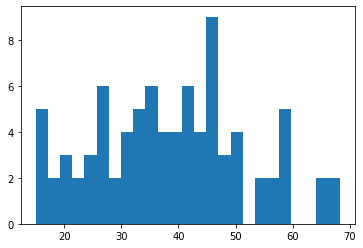

40.12472437003373

In [56]:
%matplotlib inline
user = VKUser('https://vk.com/didiv2000')
#user.friends_com.color_communities(user.friends_com.split())
plt.hist(user.friends_com.params['age_list'], bins=25)
plt.show()
user.friends_com.params['age_median']

In [15]:
print(len(activities_types))
activities_types.most_common()

370


[('Юмор', 860),
 ('Кино', 608),
 ('Городское сообщество', 563),
 ('Интернет-СМИ', 448),
 ('Обмен музыкой', 416),
 ('Творчество', 368),
 ('Публичная страница', 348),
 ('Кулинария, рецепты', 342),
 ('Литература', 304),
 ('Отношения полов', 276),
 ('Уход за собой', 255),
 ('Образование', 255),
 ('Наука', 251),
 ('ВКонтакте', 244),
 ('Объявления', 244),
 ('Общество', 235),
 ('Молодёжное движение', 224),
 ('Шоу, передача', 211),
 ('Бизнес', 209),
 ('Знакомства', 200),
 ('Здоровый образ жизни', 193),
 ('Философия', 190),
 ('Стиль, одежда, обувь', 186),
 ('Фотография', 166),
 ('Туризм, путешествия', 162),
 ('Автомобили', 148),
 ('Дизайн интерьера', 147),
 ('Музыка', 143),
 ('Игры', 134),
 ('Телеканал', 129),
 ('Родители и дети', 126),
 ('Фитнес', 125),
 ('Культура', 102),
 ('Друзья', 99),
 ('СМИ', 95),
 ('Строительство, ремонт', 89),
 ('Поиск работы', 88),
 ('Вымышленный персонаж', 86),
 ('Сайты', 85),
 ('Искусство и развлечения', 78),
 ('Rap, Hip-Hop', 74),
 ('Футбол', 74),
 ('Дискуссионный 

## Нахождение полного сообщества по нескольким участникам

In [14]:
def print_func_plot(func, params, x=None):
    results = []
    for args in params:
        results.append(func(**args))
    if x is None:
        x = range(len(results))
    plt.plot(x, results)
    plt.show()

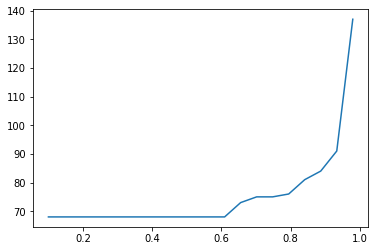

In [318]:
x = np.linspace(0.1, 0.98, num=20)
print_func_plot(
    get_community_size, 
    [
        {
            'weight_reduction_ratio': i,
            'break_point': 10,
        }
        for i in x
    ],
    x=x
)

## Нахождение общего знаменателя среди сообщества (школа, вуз, место жительста, группы вк и т.д)

In [583]:
from tqdm import tqdm_notebook as tqdm
for i in tqdm(range(2)):
    size = np.random.randint(20, 250)
    params = Community.generate_random(size).get_special_params()
#     print(params)
    CommunityData.create(data=params)

In [584]:
comm_data = [i.data for i in CommunityData.select().execute()]
def param_list(key):
    return [x[key] for x in comm_data]
params = ['community_size', 'sex_mean', 'age_median', 'city_first_fr', 
'country_first_fr', 'online_mean', 'online_mobile_mean', 
'verified_mean', 'last_seen_mean', 'last_seen_amax', 
'last_seen_median', 'site_fr', 'followers_count_mean', 
'followers_count_median', 'followers_count_amax', 'home_town_first_fr', 
'occupation_type_first_fr', 'occupation_name_first_fr', 'personal_langs_first_fr', 
'personal_political_first_fr', 'personal_religion_first_fr', 'personal_people_main_first_fr', 
'personal_smoking_first_fr', 'personal_alcohol_first_fr', 'personal_life_main_first_fr', 
'relatives_childs_fr', 'relation_first_fr', 'schools_first_fr', 
'schools_type_str_first_fr', 'status_fr']

community_size


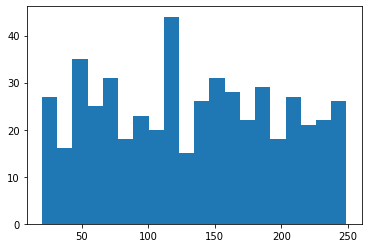

sex_mean


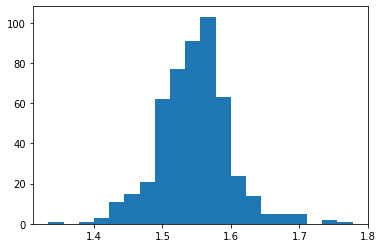

age_median


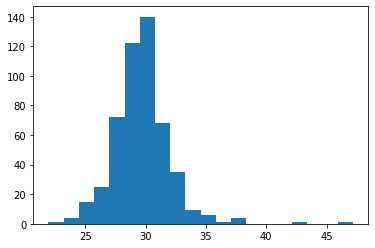

city_first_fr


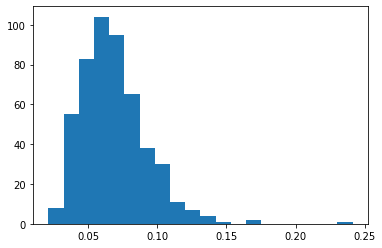

country_first_fr


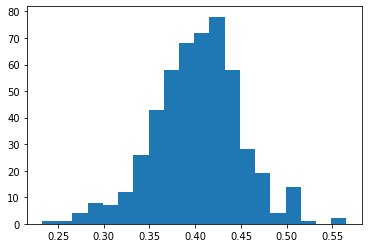

online_mean


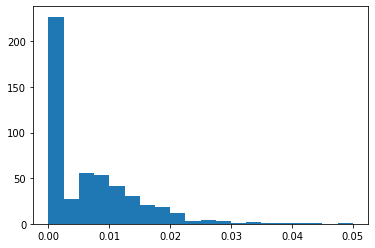

online_mobile_mean


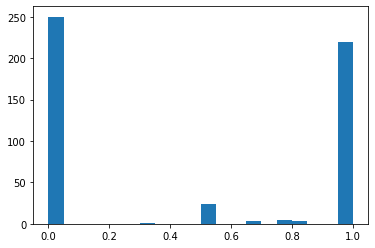

verified_mean


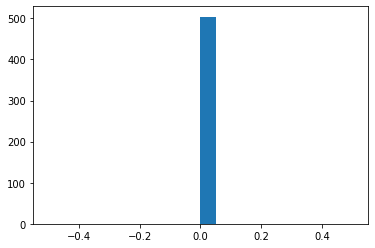

last_seen_mean


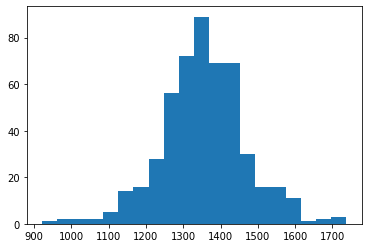

last_seen_amax


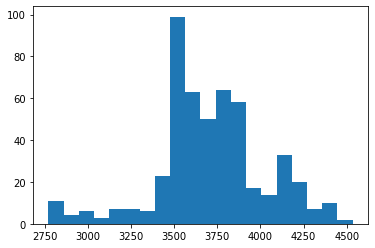

last_seen_median


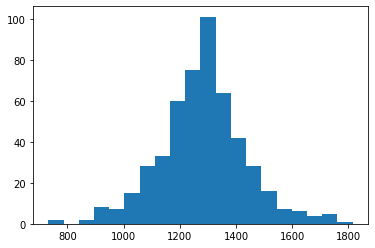

site_fr


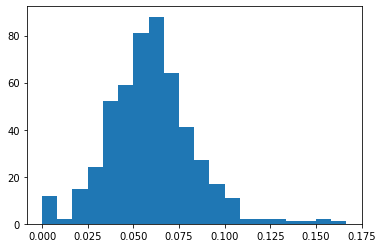

followers_count_mean


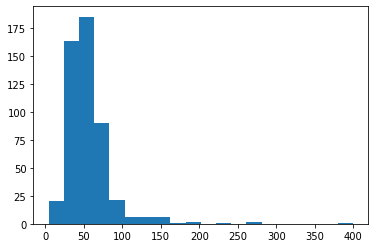

followers_count_median


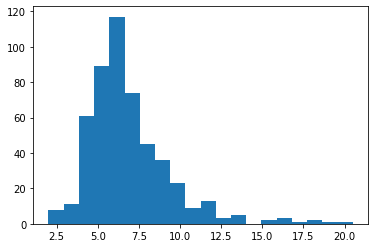

followers_count_amax


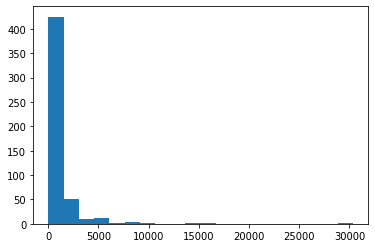

home_town_first_fr


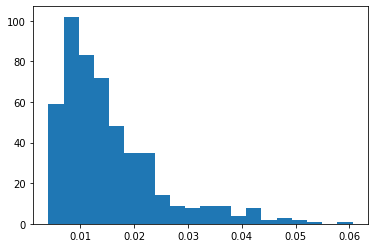

occupation_type_first_fr


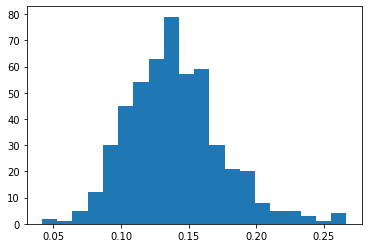

occupation_name_first_fr


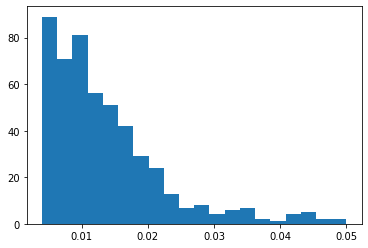

personal_langs_first_fr


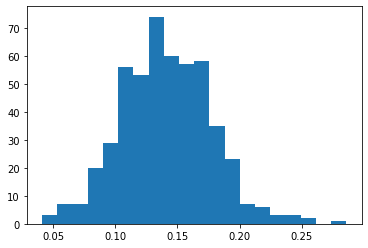

personal_political_first_fr


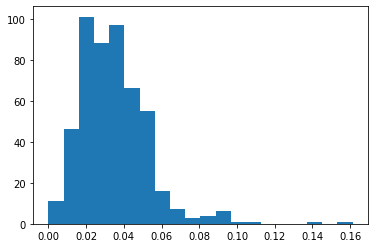

personal_religion_first_fr


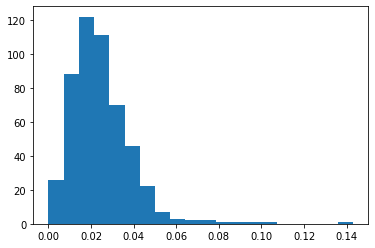

personal_people_main_first_fr


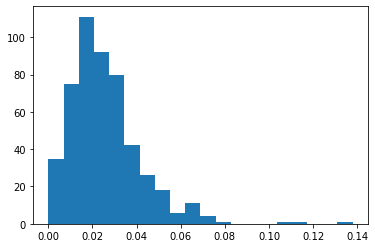

personal_smoking_first_fr


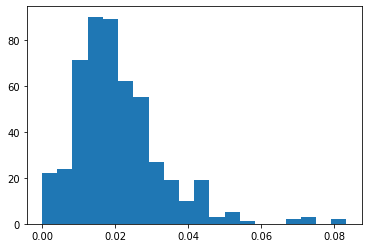

personal_alcohol_first_fr


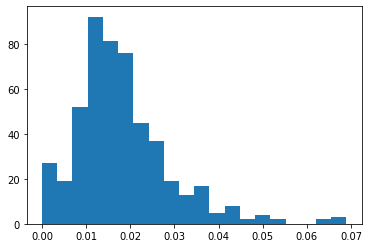

personal_life_main_first_fr


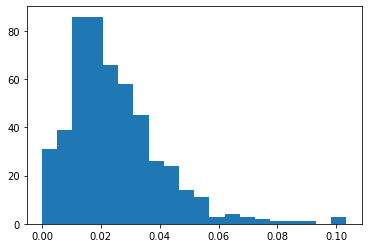

relatives_childs_fr


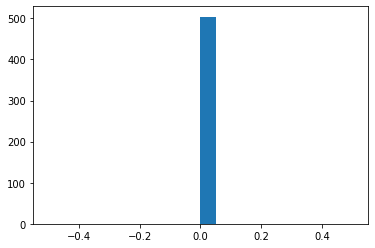

relation_first_fr


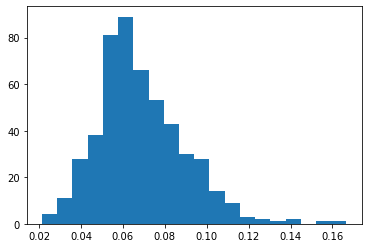

schools_first_fr


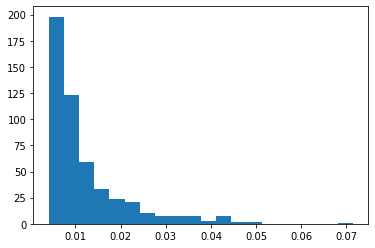

schools_type_str_first_fr


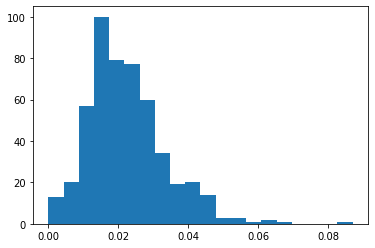

status_fr


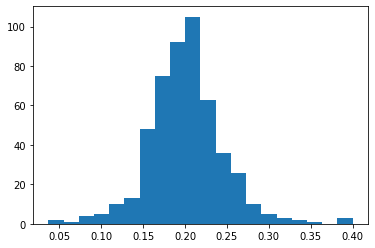

In [680]:
# Community.generate_random(1).special_params
for p in params:
    print(p)
    l = param_list(p)
    plt.hist(l, 20)
    plt.show()

In [681]:
key_importance = []
target_community = comm1.get_params()

for key in params:
    target_element = target_community[key]
#     print(target_element)
    hist_list = param_list(key)
    bins = 10
    hist_values, hist_x = np.histogram(hist_list, bins)
#     plt.hist(hist_list, bins)
#     plt.show()
#     print(hist_x)
    if target_element < hist_x[0]:
        hist_value = 0
    elif target_element > hist_x[-1]:
        hist_value = 0
    else:
        hist_column = np.where(hist_x <= target_element)[0][-1]
        hist_value = hist_values[hist_column]

    hist_max = np.max(hist_values)
    element_importance = hist_value / hist_max
    key_importance.append((element_importance, key))
#     print(hist_max)
#     print(element_fr)
[print(i) for i in sorted(key_importance)]
None

* Get user data 229170215
* Get user data 2384937
* Get user data 327191868
* Get user data 1727556
* Get user data 150879566
* Get user data 349087825
* Get user data 305752720
* Get user data 280349348
* Get user data 332072868
* Get user data 179897523
* Get user data 203419100
(0.0, 'age_median')
(0.0, 'city_first_fr')
(0.0, 'country_first_fr')
(0.0, 'followers_count_median')
(0.0, 'home_town_first_fr')
(0.0, 'last_seen_amax')
(0.0, 'last_seen_mean')
(0.0, 'last_seen_median')
(0.0, 'occupation_name_first_fr')
(0.0, 'occupation_type_first_fr')
(0.0, 'online_mean')
(0.0, 'schools_first_fr')
(0.0, 'schools_type_str_first_fr')
(0.0, 'status_fr')
(0.012, 'online_mobile_mean')
(0.07692307692307693, 'site_fr')
(0.09818181818181818, 'followers_count_mean')
(0.13664596273291926, 'personal_smoking_first_fr')
(0.20382165605095542, 'personal_alcohol_first_fr')
(0.21674876847290642, 'personal_people_main_first_fr')
(0.2261904761904762, 'sex_mean')
(0.23622047244094488, 'personal_langs_first_fr'

In [15]:
from instagram.client import InstagramAPI

client_id  = 'c6ab41f3c1094082aadf0cc0c6c4bb27'
client_secret = '16a8afe3350a43d697ac5138881c94fc'
access_token = '12638820603.c6ab41f.cad5b7d0690b496691583fc689a03b10'

api = InstagramAPI(client_id=client_id, client_secret=client_secret, access_token=access_token)

follows, next_ = api.user_follows()

InstagramAPIError: (400) OAuthPermissionsException-This request requires scope=follower_list, but this access token is not authorized with this scope. The user must re-authorize your application with scope=follower_list to be granted this permissions.

In [16]:
from instagram.client import InstagramAPI
import sys

if len(sys.argv) > 1 and sys.argv[1] == 'local':
    try:
        from test_settings import *

        InstagramAPI.host = test_host
        InstagramAPI.base_path = test_base_path
        InstagramAPI.access_token_field = "access_token"
        InstagramAPI.authorize_url = test_authorize_url
        InstagramAPI.access_token_url = test_access_token_url
        InstagramAPI.protocol = test_protocol
    except Exception:
        pass

# Fix Python 2.x.
try:
    import __builtin__
    input = getattr(__builtin__, 'raw_input')
except (ImportError, AttributeError):
    pass

client_id = input("Client ID: ").strip()
client_secret = input("Client Secret: ").strip()
redirect_uri = input("Redirect URI: ").strip()
raw_scope = input("Requested scope (separated by spaces, blank for just basic read): ").strip()
scope = raw_scope.split(' ')
# For basic, API seems to need to be set explicitly
if not scope or scope == [""]:
    scope = ["basic"]

api = InstagramAPI(client_id=client_id, client_secret=client_secret, redirect_uri=redirect_uri)
redirect_uri = api.get_authorize_login_url(scope = scope)

print ("Visit this page and authorize access in your browser: "+ redirect_uri)

code = (str(input("Paste in code in query string after redirect: ").strip()))

access_token = api.exchange_code_for_access_token(code)
print ("access token: " )
print (access_token)



Client ID: c6ab41f3c1094082aadf0cc0c6c4bb27
Client Secret: 16a8afe3350a43d697ac5138881c94fc
Redirect URI: https://rudrastyh.com/tools/access-token


KeyboardInterrupt: 

In [1]:
from instagram import Account, Media, WebAgent

agent = WebAgent()
account = Account("fivol5")

# media_objects, pointer = agent.get_media(account)
media, pointer = agent.get_media(account, count=20, delay=1)

In [58]:
# obj = media1[3]
# for item in dir(obj):
#     print(item, getattr(obj, item))

In [79]:
keys = ['caption', 'date', 'display_url', 'likes_count', 'comments_count']
for obj in media_objects:
    print(obj.display_url)

https://scontent-amt2-1.cdninstagram.com/vp/1b57e342eaf4c8802078f1ab01c541aa/5E24A260/t51.2885-15/e35/71024929_232709697697918_8404479157268540884_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=110
https://scontent-amt2-1.cdninstagram.com/vp/bd544b9ced95cc3ca29ed2f98f0ceb89/5E1758BD/t51.2885-15/e35/69357277_107572600505017_2119080385914866789_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=101
https://scontent-amt2-1.cdninstagram.com/vp/85672d75945507b84be01460634949f7/5E04AC80/t51.2885-15/e35/69805450_133553997927918_5874482647860257742_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=106
https://scontent-amt2-1.cdninstagram.com/vp/4d579b5be46908036d95f0c98ee63310/5E3675F1/t51.2885-15/e35/69143631_493140504832604_7395125488741647540_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=108
https://scontent-amt2-1.cdninstagram.com/vp/8befc8ddc30cc25112ee8bac6387a86c/5E16AC4A/t51.2885-15/e35/69078067_755965958172567_6808493308163585663_n.jpg?_nc_ht=scontent-amt2-1.cdni

In [3]:
from instagram import WebAgentAccount
from instagram import Account, Media, WebAgent

# agent = WebAgentAccount("fivol5")
# agent.auth('dlz08UtKFinst')

agent2 = WebAgentAccount('borfiner')
agent2.auth('dlz08UtKFfivol')
# f = agent2.get_follows(Account('cuvoe'), delay=0)[0]
# f = agent.get_follows(Account('cuvoe'), delay=0, count=100)[0]
agent2.username

'borfiner'

In [17]:
data, pointer = agent.get_follows(Account('cuvoe'), delay=0)
data2 = agent2.get_follows(pointer=pointer, delay=0)[0]
# print(data)
print(data, data2)

[taetaebooo, jypetwicenayeon, killrtaekook, _s.kripton_, svyatalina, essie_amy334, msuga1628, diakka__, astmodeus, yukokiro, mikialiet, the.kurb, my_afterglow_, jisoo.mp4, larkicheva, ester_exposito, jung_mariia, ugllliver.r, orthvs, jhopetv] [on_seish, al.boss006, mishalaz, kirillovphoto, vladomot]


In [27]:
for i in f:
    print(i)
    d = agent2.get_follows(Account(i), count=100, delay=0)[0]
    print(d)

taetaebooo
[malive.art, fabxiao, vanillahobie, bts.biighitofical, hannes_becker, koosarchive, shooky_dough, reiz_i, chungha_official, bts.world.official, koalaguk, iamhalsey, randomsplashes, kookiechimm, 2ah.in, hyundai.lifestyle, for__infinity, jiminskth, boo.archive, miyayeah, bn_sj2013, selenaspiral, ireneisgood, dora._.a, debaek, kimtaehyungscloset, winter_strawverry, _nuna_v, bt21club, mejiwoo103, bts_love_myself, bt21_official, sonsungdeuk, bighit_exhibition, bts.bighitofficial]
jypetwicenayeon
[renebaebae, twiceetweets, kym1222, im_cuck_oo, _imyour_joy, yeojin9oo, _happiness_o, ppong_ling, lesyeuxdenini, txt_bighit, han_bling_, sc__0322, jiyeon2__, geewonii, sweetthyunjin, damhee_00, abproject.official, seyoung__0203, cho.jiii, official_everglow, baifernbah, songjoongkionly, kyo1122, realllllmino, twicetagram, 3riii_0.k, hi_sseulgi, xeesoxee, petalhyunjin, shxxbi131, imhyoseop, yerimiese, chaeryeongfacts, hearthyunjins, nct127, itzy.all.in.us, hyunjinjyp, skz.straykids, straykid

[hisokafisting, simonakust, discosunniva, vivotattoo, sm_____tattoo, tattooist_mijeongwon, photohelll, lilli.ptz, svyatalina, _s.kripton_, astmodeus, javi.borrego, kulikulikulik, maratneva, titomerello, badgalriri, bymysidekookv, kedavra.art, voguemagazine, frejaerichsen, dididediego, manurios, simihaze, for_ladies_ua, jjjytikus, codyfern, designclass_odessa, _s.o.c.k.s, jessiehark_, flesh.png, naeriy, toface_ukraine, basquiatart, bohemianxse, _ul.na, xxmalato.jpg, darararm, xxiujj, chey_maya, vetements_official, kasiqjungwoo, itsnotsonia, michiko_malandro_, myaso_gorit, costarastrology, galaktionova_nastya, calvinklein, blonded, thegorgeousbane, areyouami, luv_jayne, for__infinity, doo.jk, nogobed, dianasilverss, mayonezusuki, pomogisebe, rommroom, case.she, pprofessorr, jacobbix, queenvelv, shooky_dough, dracarysgang, katemoss90s, thetogfather, hi_sseulgi, asaprocky, chiitan7407, jihobts, r._.kiya, _shoproishodit_, bts.bighitofficial, _imyour_joy, clara.berry, darjjap, shaaantiiiiiii